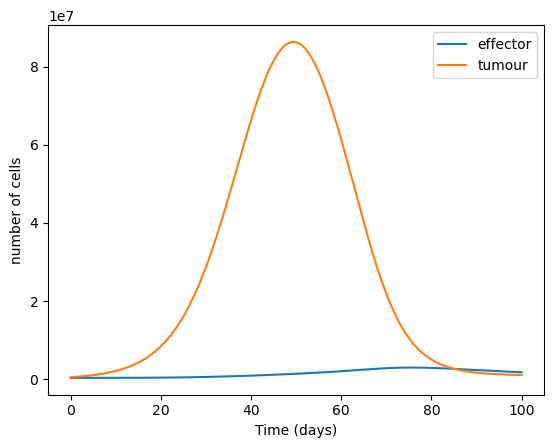

In [50]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# reduced model

def model(t,y):
    E, T = y
    dE = s + p*E*T / (g+T) - m*E*T - d*E
    dT = a*T*(1-b*T) - n*E*T

    return [dE, dT]
# parameters

a = 0.18
b = 2.0e-9
s = 1.3e4
p = 0.1245
m = 3.422e-10
g = 2.019e7
n = 1.101e-7
d = 0.0412

E0 = 3.2e5
T0 = 5e5
y0 = [E0, T0]

t_span = (0,100)
t_eval = np.linspace(0,100,2000)

solution = solve_ivp(model, t_span, y0, t_eval=t_eval)

plt.plot(solution.t, solution.y[0], label = "effector")
plt.plot(solution.t, solution.y[1], label = "tumour")
plt.xlabel("Time (days)")
plt.ylabel("number of cells")
plt.legend()
plt.show()


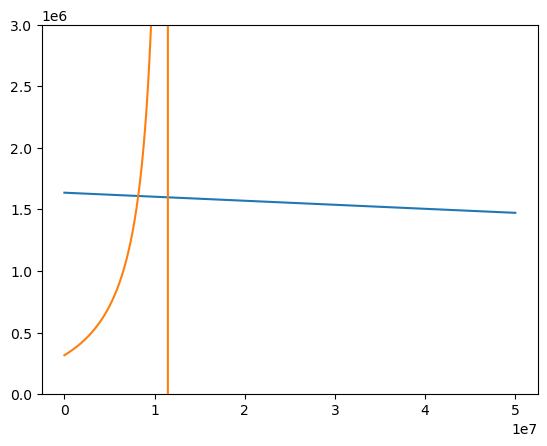

In [51]:
# nullclines

T_values = np.linspace(0, 5e7, 5000)
E1_values = a*(1-b*T_values)/ n
E2_values = s*(g+T_values) / ((m*T_values+d)*(g+T_values) - p*T_values)

plt.plot(T_values, E1_values)
plt.plot(T_values, E2_values)
plt.ylim(0, 3e6)
plt.show()

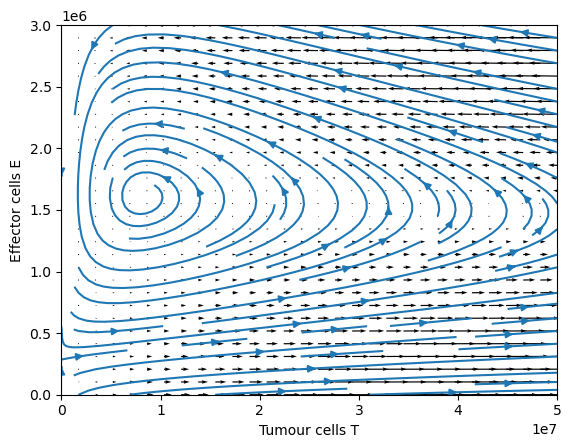

In [52]:
T_values = np.linspace(0, 5e7, 30)
E_values = np.linspace(0,3e6, 30)

T_grid, E_grid = np.meshgrid(T_values, E_values)

dE = s + p*E_grid*T_grid/(g+T_grid) - m*E_grid*T_grid - d*E_grid
dT = a*T_grid*(1-b*T_grid) - n*E_grid*T_grid

plt.streamplot(T_grid, E_grid, dT, dE)
plt.quiver(T_grid, E_grid, dT, dE)
plt.xlabel("Tumour cells T")
plt.ylabel("Effector cells E")
plt.show()